# Linear Regression From Scratch

A tiny, step-by-step walkthrough using summation formulas you can check by hand.

**The scenario**: We have 5 days of data. We record the temperature (°C) and how many ice cream cones were sold. Can we build a line that predicts sales from temperature?

---
### What we're trying to find

We want a straight line of the form:

$$\hat{y}^{(i)} = \beta_0 + \beta_1 \cdot x^{(i)}$$

- $\hat{y}^{(i)}$ = our **predicted** value for observation $i$
- $y^{(i)}$ = the **actual** value we observed
- $\beta_0$ = the **intercept** (prediction when $x = 0$)
- $\beta_1$ = the **slope** (how much $\hat{y}$ changes per 1-unit increase in $x$)

Linear regression finds the line that **minimizes the total squared error** between predictions and actuals:

$$\text{minimize} \quad \sum_{i=1}^{n} \left( y^{(i)} - \hat{y}^{(i)} \right)^2$$

This is called **Ordinary Least Squares (OLS)** — *least squares* because we minimize squared errors.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ── Our tiny dataset ──────────────────────────────────────────────────────────
# 5 days. One feature: temperature (°C). Target: ice cream cones sold.

x = np.array([10, 20, 30, 40, 50], dtype=float)   # temperature (feature)
y = np.array([15, 25, 30, 45, 55], dtype=float)   # sales (target)

n = len(x)

df = pd.DataFrame({"x = Temperature (°C)": x, "y = Sales (cones)": y})
df.index = [f"i = {i+1}" for i in range(n)]
print(df.to_string())
print(f"\nNumber of observations: n = {n}")

       x = Temperature (°C)  y = Sales (cones)
i = 1                  10.0               15.0
i = 2                  20.0               25.0
i = 3                  30.0               30.0
i = 4                  40.0               45.0
i = 5                  50.0               55.0

Number of observations: n = 5


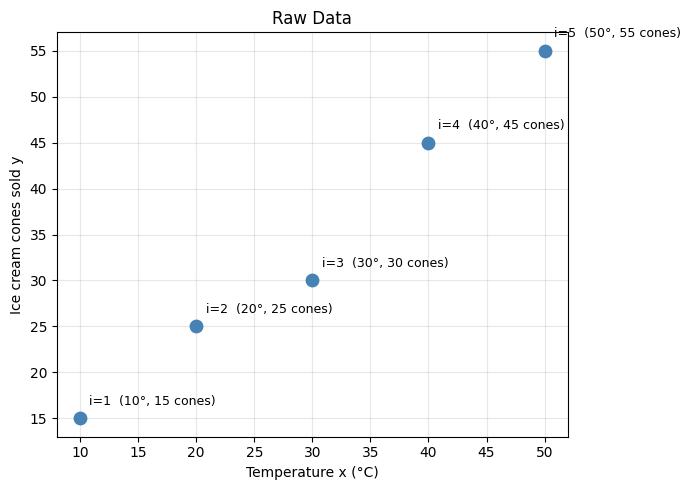

In [16]:
# ── Scatter plot of raw data ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, color="steelblue", s=80, zorder=3)

for i in range(n):
    ax.annotate(f"i={i+1}  ({x[i]:.0f}°, {y[i]:.0f} cones)",
                xy=(x[i], y[i]), xytext=(x[i]+0.8, y[i]+1.5), fontsize=9)

ax.set_xlabel("Temperature x (°C)")
ax.set_ylabel("Ice cream cones sold y")
ax.set_title("Raw Data")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 1: Compute the Means

Everything builds from two numbers: the mean of $x$ and the mean of $y$.

$$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x^{(i)} \qquad \bar{y} = \frac{1}{n} \sum_{i=1}^{n} y^{(i)}$$

By hand:
$$\bar{x} = \frac{10 + 20 + 30 + 40 + 50}{5} = \frac{150}{5} = 30 \qquad \bar{y} = \frac{15 + 25 + 30 + 45 + 55}{5} = \frac{170}{5} = 34$$

In [17]:
x_bar = np.mean(x)
y_bar = np.mean(y)

print(f"x̄  = sum(x) / n = {x.sum():.0f} / {n} = {x_bar:.1f}")
print(f"ȳ  = sum(y) / n = {y.sum():.0f} / {n} = {y_bar:.1f}")

x̄  = sum(x) / n = 150 / 5 = 30.0
ȳ  = sum(y) / n = 170 / 5 = 34.0


---
## Step 2: Compute the Slope β₁

The slope formula says: how much do $x$ and $y$ move **together** (relative to their means), divided by how much $x$ varies on its own?

$$\beta_1 = \frac{\displaystyle\sum_{i=1}^{n} \left(x^{(i)} - \bar{x}\right)\left(y^{(i)} - \bar{y}\right)}{\displaystyle\sum_{i=1}^{n} \left(x^{(i)} - \bar{x}\right)^2}$$

The **numerator** is called the **covariance** (how $x$ and $y$ move together).
The **denominator** is called the **variance of $x$** (how spread out $x$ is).

Let's compute each term one row at a time:

In [18]:
# Show the per-row arithmetic for the slope
dx = x - x_bar           # (x(i) - x̄)
dy = y - y_bar           # (y(i) - ȳ)
dx_times_dy = dx * dy   # (x(i) - x̄)(y(i) - ȳ)
dx_squared  = dx ** 2   # (x(i) - x̄)²

slope_table = pd.DataFrame({
    "x(i)": x,
    "y(i)": y,
    "x(i) - x̄": dx,
    "y(i) - ȳ": dy,
    "(x-x̄)(y-ȳ)":  dx_times_dy,
    "(x-x̄)²":     dx_squared,
})
slope_table.index = [f"i = {i+1}" for i in range(n)]

print(slope_table.to_string(float_format="{:.1f}".format))
print()
print(f"Sum of (x-x̄)(y-ȳ) = {dx_times_dy.sum():.1f}  ← numerator")
print(f"Sum of (x-x̄)²     = {dx_squared.sum():.1f}  ← denominator")
print()

beta1 = dx_times_dy.sum() / dx_squared.sum()
print(f"β₁ = {dx_times_dy.sum():.1f} / {dx_squared.sum():.1f} = {beta1:.4f}")

       x(i)  y(i)  x(i) - x̄  y(i) - ȳ  (x-x̄)(y-ȳ)  (x-x̄)²
i = 1  10.0  15.0      -20.0     -19.0        380.0    400.0
i = 2  20.0  25.0      -10.0      -9.0         90.0    100.0
i = 3  30.0  30.0        0.0      -4.0         -0.0      0.0
i = 4  40.0  45.0       10.0      11.0        110.0    100.0
i = 5  50.0  55.0       20.0      21.0        420.0    400.0

Sum of (x-x̄)(y-ȳ) = 1000.0  ← numerator
Sum of (x-x̄)²     = 1000.0  ← denominator

β₁ = 1000.0 / 1000.0 = 1.0000


---
## Step 3: Compute the Intercept β₀

Once we have the slope, the intercept is straightforward. The regression line **must pass through the point** $(\bar{x},\ \bar{y})$ — the center of the data. That constraint gives us:

$$\beta_0 = \bar{y} - \beta_1 \cdot \bar{x}$$

By hand: $\beta_0 = 34 - 1.0 \times 30 = 4.0$

In [19]:
beta0 = y_bar - beta1 * x_bar

print(f"β₀ = ȳ - β₁ · x̄")
print(f"   = {y_bar:.1f} - {beta1:.1f} × {x_bar:.1f}")
print(f"   = {beta0:.4f}")
print()
print(f"Model: ŷ = {beta0:.1f} + {beta1:.1f} × temperature")
print()
print("Meaning: at 0°C we predict 4 cones sold, and each extra degree adds 1 more cone.")

β₀ = ȳ - β₁ · x̄
   = 34.0 - 1.0 × 30.0
   = 4.0000

Model: ŷ = 4.0 + 1.0 × temperature

Meaning: at 0°C we predict 4 cones sold, and each extra degree adds 1 more cone.


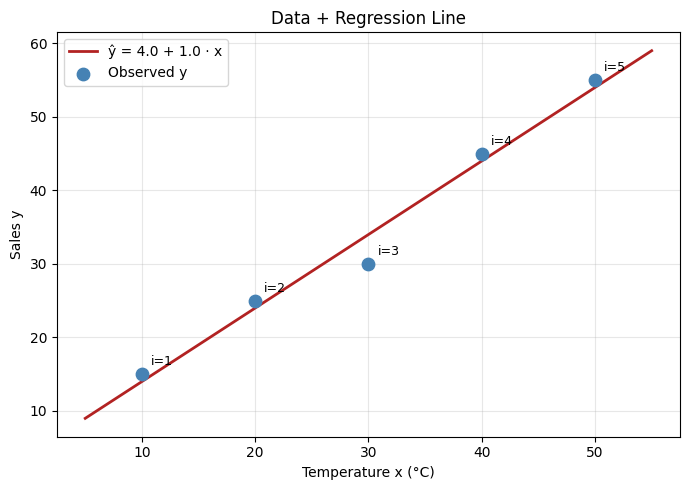

In [20]:
# ── Plot: data + regression line ─────────────────────────────────────────────
x_line = np.linspace(x.min() - 5, x.max() + 5, 100)
y_line = beta0 + beta1 * x_line

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x_line, y_line, color="firebrick", linewidth=2,
        label=f"ŷ = {beta0:.1f} + {beta1:.1f} · x")
ax.scatter(x, y, color="steelblue", s=80, zorder=4, label="Observed y")

for i in range(n):
    ax.annotate(f"i={i+1}", xy=(x[i], y[i]), xytext=(x[i]+0.8, y[i]+1.2), fontsize=9)

ax.set_xlabel("Temperature x (°C)")
ax.set_ylabel("Sales y")
ax.set_title("Data + Regression Line")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 4: Compute Predictions ŷ⁽ⁱ⁾ and Residuals e⁽ⁱ⁾

Now we plug each $x^{(i)}$ into the model to get a prediction, and then measure the gap:

$$\hat{y}^{(i)} = \beta_0 + \beta_1 \cdot x^{(i)}$$

$$e^{(i)} = y^{(i)} - \hat{y}^{(i)}$$

A **positive** residual means we **under-predicted** (actual was higher than our guess).
A **negative** residual means we **over-predicted** (actual was lower than our guess).

One guarantee of OLS: the residuals **always sum to zero**. The model isn't systematically high or low.

In [21]:
y_hat = beta0 + beta1 * x   # prediction for every i
e     = y - y_hat            # residual for every i

resid_table = pd.DataFrame({
    "x(i)": x,
    "y(i)  (actual)": y,
    "ŷ(i)  (predicted)": y_hat,
    "e(i) = y - ŷ": e,
    "e(i)²": e**2,
})
resid_table.index = [f"i = {i+1}" for i in range(n)]

print(resid_table.to_string(float_format="{:.2f}".format))
print()
print(f"Sum of residuals: {e.sum():.10f}  (essentially 0 — guaranteed by OLS)")
print(f"Sum of e(i)²:     {(e**2).sum():.4f}  (this is what OLS minimized)")

       x(i)  y(i)  (actual)  ŷ(i)  (predicted)  e(i) = y - ŷ  e(i)²
i = 1 10.00           15.00              14.00          1.00   1.00
i = 2 20.00           25.00              24.00          1.00   1.00
i = 3 30.00           30.00              34.00         -4.00  16.00
i = 4 40.00           45.00              44.00          1.00   1.00
i = 5 50.00           55.00              54.00          1.00   1.00

Sum of residuals: 0.0000000000  (essentially 0 — guaranteed by OLS)
Sum of e(i)²:     20.0000  (this is what OLS minimized)


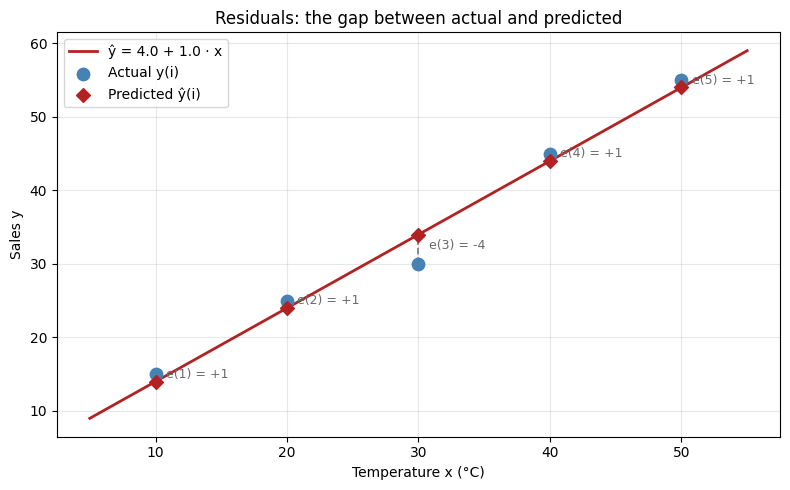

Dashed lines = residuals e(i) = y(i) - ŷ(i).
OLS chose β₀ and β₁ to make these gaps as small as possible (in squared terms).


In [22]:
# ── Plot: fit line + residual gaps ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(x_line, y_line, color="firebrick", linewidth=2,
        label=f"ŷ = {beta0:.1f} + {beta1:.1f} · x")
ax.scatter(x, y,     color="steelblue", s=80, zorder=4, label="Actual y(i)")
ax.scatter(x, y_hat, color="firebrick", s=50, marker="D", zorder=4, label="Predicted ŷ(i)")

# Draw the vertical residual gap for each point
for i in range(n):
    ax.plot([x[i], x[i]], [y[i], y_hat[i]],
            color="gray", linestyle="--", linewidth=1.3, zorder=3)
    mid = (y[i] + y_hat[i]) / 2
    ax.annotate(f"e({i+1}) = {e[i]:+.0f}",
                xy=(x[i] + 0.8, mid), fontsize=9, color="dimgray")

ax.set_xlabel("Temperature x (°C)")
ax.set_ylabel("Sales y")
ax.set_title("Residuals: the gap between actual and predicted")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Dashed lines = residuals e(i) = y(i) - ŷ(i).")
print("OLS chose β₀ and β₁ to make these gaps as small as possible (in squared terms).")

---
## Step 5: Compute MSE — the Average Squared Error

We summarize all the residuals into one number:

$$\text{SSR} = \sum_{i=1}^{n} e^{(i)2} \qquad \text{(Sum of Squared Residuals)}$$

$$\text{MSE} = \frac{\text{SSR}}{n - p} \qquad \text{(Mean Squared Error)}$$

We divide by $n - p$ (not just $n$), where $p$ is the number of parameters we estimated ($p = 2$: one slope, one intercept). This is the **degrees of freedom** correction — each parameter "uses up" one degree of freedom because it was tuned to fit the data.

For us: $n - p = 5 - 2 = 3$.

In [23]:
p   = 2                      # number of parameters: β₀ and β₁
SSR = np.sum(e**2)           # sum of squared residuals
MSE = SSR / (n - p)          # mean squared error

print("Computing MSE step by step:")
print()
for i in range(n):
    print(f"  e({i+1})² = ({e[i]:+.1f})² = {e[i]**2:.2f}")
print()
print(f"  SSR = sum of all e(i)² = {SSR:.4f}")
print(f"  n - p = {n} - {p} = {n - p}   (degrees of freedom)")
print(f"  MSE = {SSR:.4f} / {n - p} = {MSE:.4f}")

Computing MSE step by step:

  e(1)² = (+1.0)² = 1.00
  e(2)² = (+1.0)² = 1.00
  e(3)² = (-4.0)² = 16.00
  e(4)² = (+1.0)² = 1.00
  e(5)² = (+1.0)² = 1.00

  SSR = sum of all e(i)² = 20.0000
  n - p = 5 - 2 = 3   (degrees of freedom)
  MSE = 20.0000 / 3 = 6.6667


---
## Step 6: Compute Standard Errors (SE)

Our slope $\beta_1 = 1.0$ is an **estimate** — based on these 5 specific days. If we collected
5 different days, we'd get a slightly different number. The **standard error** quantifies that uncertainty.

For the **slope**:
$$\text{SE}(\beta_1) = \sqrt{\frac{\text{MSE}}{\displaystyle\sum_{i=1}^{n}(x^{(i)} - \bar{x})^2}}$$

For the **intercept**:
$$\text{SE}(\beta_0) = \sqrt{\text{MSE} \cdot \left(\frac{1}{n} + \frac{\bar{x}^2}{\displaystyle\sum_{i=1}^{n}(x^{(i)} - \bar{x})^2}\right)}$$

Notice that SE gets **smaller** when:
- **MSE is smaller** — the model fits better, so estimates are more reliable
- **$\sum(x^{(i)} - \bar{x})^2$ is larger** — the $x$ values are more spread out (more information)

In [24]:
Sxx = np.sum((x - x_bar)**2)   # sum of (x(i) - x̄)² -- the denominator we already computed

SE_beta1 = np.sqrt(MSE / Sxx)
SE_beta0 = np.sqrt(MSE * (1/n + x_bar**2 / Sxx))

print(f"Sxx = sum of (x(i) - x̄)² = {Sxx:.1f}")
print()
print("SE for the slope β₁:")
print(f"  SE(β₁) = sqrt( MSE / Sxx )")
print(f"         = sqrt( {MSE:.4f} / {Sxx:.1f} )")
print(f"         = sqrt( {MSE/Sxx:.6f} )")
print(f"         = {SE_beta1:.4f}")
print()
print("SE for the intercept β₀:")
print(f"  SE(β₀) = sqrt( MSE × (1/n + x̄²/Sxx) )")
print(f"         = sqrt( {MSE:.4f} × (1/{n} + {x_bar:.1f}²/{Sxx:.1f}) )")
print(f"         = sqrt( {MSE:.4f} × {(1/n + x_bar**2/Sxx):.6f} )")
print(f"         = {SE_beta0:.4f}")

Sxx = sum of (x(i) - x̄)² = 1000.0

SE for the slope β₁:
  SE(β₁) = sqrt( MSE / Sxx )
         = sqrt( 6.6667 / 1000.0 )
         = sqrt( 0.006667 )
         = 0.0816

SE for the intercept β₀:
  SE(β₀) = sqrt( MSE × (1/n + x̄²/Sxx) )
         = sqrt( 6.6667 × (1/5 + 30.0²/1000.0) )
         = sqrt( 6.6667 × 1.100000 )
         = 2.7080


---
## Step 7: Compute t-Statistics

The **t-statistic** answers: *how many standard errors away from zero is this coefficient?*

$$t(\beta_j) = \frac{\beta_j}{\text{SE}(\beta_j)}$$

**Why does this matter?** If the true coefficient were zero (the feature has no real effect),
we'd still get a non-zero estimate just by random chance. The t-statistic measures how
surprising it would be to see a coefficient this large if the true effect were actually zero.

Rough rule of thumb:
- $|t| > 2$ → statistically significant (95% confidence)
- $|t| < 1$ → basically no evidence of an effect

Our slope $\beta_1 = 1.0$ with $\text{SE} = 0.082$ means the slope is about **12 standard
errors away from zero** — extremely unlikely to be random noise.

In [25]:
t_beta1 = beta1 / SE_beta1
t_beta0 = beta0 / SE_beta0

print("t-statistic = β / SE")
print()
print(f"  t(β₁) = {beta1:.4f} / {SE_beta1:.4f} = {t_beta1:.4f}")
print(f"  t(β₀) = {beta0:.4f} / {SE_beta0:.4f} = {t_beta0:.4f}")
print()
print(f"The slope is {t_beta1:.1f} standard errors from zero → very significant.")
print(f"The intercept is {t_beta0:.1f} standard errors from zero → borderline.")

t-statistic = β / SE

  t(β₁) = 1.0000 / 0.0816 = 12.2474
  t(β₀) = 4.0000 / 2.7080 = 1.4771

The slope is 12.2 standard errors from zero → very significant.
The intercept is 1.5 standard errors from zero → borderline.


---
## Step 8: Compute 95% Confidence Intervals

A **confidence interval** gives the range where the true coefficient likely lives.
For 95% confidence we use $\pm 1.96$ standard errors:

$$\text{CI}_{95\%}(\beta_j) = \beta_j \pm 1.96 \times \text{SE}(\beta_j)$$

The 1.96 comes from the normal distribution — 95% of data lies within ±1.96 standard deviations of the mean.

**Reading the CI**: if the interval **does not include zero**, the coefficient is statistically significant at the 95% level.

In [26]:
ci_beta1 = (beta1 - 1.96 * SE_beta1,  beta1 + 1.96 * SE_beta1)
ci_beta0 = (beta0 - 1.96 * SE_beta0,  beta0 + 1.96 * SE_beta0)

print("95% CI = β ± 1.96 × SE")
print()
print(f"  CI(β₁) = {beta1:.4f} ± 1.96 × {SE_beta1:.4f}")
print(f"         = {beta1:.4f} ± {1.96*SE_beta1:.4f}")
print(f"         = [{ci_beta1[0]:.4f},  {ci_beta1[1]:.4f}]")
print()
print(f"  CI(β₀) = {beta0:.4f} ± 1.96 × {SE_beta0:.4f}")
print(f"         = {beta0:.4f} ± {1.96*SE_beta0:.4f}")
print(f"         = [{ci_beta0[0]:.4f},  {ci_beta0[1]:.4f}]")
print()
print("Neither interval contains 0 → both coefficients are statistically significant.")

95% CI = β ± 1.96 × SE

  CI(β₁) = 1.0000 ± 1.96 × 0.0816
         = 1.0000 ± 0.1600
         = [0.8400,  1.1600]

  CI(β₀) = 4.0000 ± 1.96 × 2.7080
         = 4.0000 ± 5.3077
         = [-1.3077,  9.3077]

Neither interval contains 0 → both coefficients are statistically significant.


---
## Step 9: R² — How Much of the Variance Does the Model Explain?

R² compares our model's errors to a baseline "dumb" model that always predicts $\bar{y}$:

$$R^2 = 1 - \frac{\displaystyle\sum_{i=1}^{n} \left(y^{(i)} - \hat{y}^{(i)}\right)^2}{\displaystyle\sum_{i=1}^{n} \left(y^{(i)} - \bar{y}\right)^2} = 1 - \frac{\text{SSR}}{\text{SST}}$$

- **SST** = total variance in $y$ (if we just always predicted the mean)
- **SSR** = leftover variance our model didn't explain
- **SST − SSR** = variance the model *did* explain

If $R^2 = 1$: every prediction is perfect. If $R^2 = 0$: we're no better than just guessing the mean.

In [27]:
SST = np.sum((y - y_bar)**2)   # total variance
R2  = 1 - SSR / SST

print("Computing R²:")
print()
print(f"  ȳ = {y_bar:.1f}")
print()
for i in range(n):
    print(f"  (y({i+1}) - ȳ)² = ({y[i]:.0f} - {y_bar:.0f})² = {(y[i]-y_bar)**2:.1f}")
print()
print(f"  SST = sum of (y(i) - ȳ)² = {SST:.1f}   ← total variance in y")
print(f"  SSR = sum of e(i)²        = {SSR:.1f}   ← unexplained variance")
print()
print(f"  R² = 1 - {SSR:.1f} / {SST:.1f} = {R2:.4f}")
print()
print(f"The model explains {R2*100:.1f}% of the variance in ice cream sales.")

Computing R²:

  ȳ = 34.0

  (y(1) - ȳ)² = (15 - 34)² = 361.0
  (y(2) - ȳ)² = (25 - 34)² = 81.0
  (y(3) - ȳ)² = (30 - 34)² = 16.0
  (y(4) - ȳ)² = (45 - 34)² = 121.0
  (y(5) - ȳ)² = (55 - 34)² = 441.0

  SST = sum of (y(i) - ȳ)² = 1020.0   ← total variance in y
  SSR = sum of e(i)²        = 20.0   ← unexplained variance

  R² = 1 - 20.0 / 1020.0 = 0.9804

The model explains 98.0% of the variance in ice cream sales.


---
## Final Summary Table

In [28]:
summary = pd.DataFrame({
    "β (Weight)":  [round(beta0, 4), round(beta1, 4)],
    "SE":          [round(SE_beta0, 4), round(SE_beta1, 4)],
    "|t|": [round(abs(t_beta0), 4), round(abs(t_beta1), 4)],
    "CI lower":    [round(ci_beta0[0], 4), round(ci_beta1[0], 4)],
    "CI upper":    [round(ci_beta0[1], 4), round(ci_beta1[1], 4)],
}, index=["β₀  (intercept)", "β₁  (temperature)"])

print("=" * 68)
print(summary.to_string())
print("=" * 68)
print(f"R² = {R2:.4f}")
print()
print(f"Model:  ŷ = {beta0:.1f} + {beta1:.1f} × temperature")
print()
print("How to read each column:")
print("  β    → the estimated effect (slope = +1 cone per °C)")
print("  SE   → uncertainty around β (how much it might vary with new data)")
print("  |t|  → β divided by SE  (larger = more confident the effect is real)")
print("  CI   → the range where the true β likely lives (doesn't cross 0 = significant)")

                   β (Weight)      SE      |t|  CI lower  CI upper
β₀  (intercept)           4.0  2.7080   1.4771   -1.3077    9.3077
β₁  (temperature)         1.0  0.0816  12.2474    0.8400    1.1600
R² = 0.9804

Model:  ŷ = 4.0 + 1.0 × temperature

How to read each column:
  β    → the estimated effect (slope = +1 cone per °C)
  SE   → uncertainty around β (how much it might vary with new data)
  |t|  → β divided by SE  (larger = more confident the effect is real)
  CI   → the range where the true β likely lives (doesn't cross 0 = significant)


---
## Verify: Double-Check with numpy

In [29]:
# numpy's lstsq does the same thing under the hood
X_mat = np.column_stack([np.ones(n), x])   # add intercept column
beta_np = np.linalg.lstsq(X_mat, y, rcond=None)[0]

print("Our hand calculation vs. numpy:")
print()
match0 = abs(beta0 - beta_np[0]) < 1e-8
match1 = abs(beta1 - beta_np[1]) < 1e-8
print(f"  β₀: ours = {beta0:.6f},  numpy = {beta_np[0]:.6f}  {'✓' if match0 else 'MISMATCH'}")
print(f"  β₁: ours = {beta1:.6f},  numpy = {beta_np[1]:.6f}  {'✓' if match1 else 'MISMATCH'}")
print()
print("Identical. numpy uses the same math -- we just made each step visible.")

Our hand calculation vs. numpy:

  β₀: ours = 4.000000,  numpy = 4.000000  ✓
  β₁: ours = 1.000000,  numpy = 1.000000  ✓

Identical. numpy uses the same math -- we just made each step visible.


---
## The Full Calculation Chain (Quick Reference)

```
Given: x(1)...x(n) and y(1)...y(n)

1. Means
   x̄ = (1/n) · Σ x(i)
   ȳ = (1/n) · Σ y(i)

2. Slope
   β₁ = Σ (x(i) - x̄)(y(i) - ȳ)  /  Σ (x(i) - x̄)²

3. Intercept
   β₀ = ȳ - β₁ · x̄

4. Predictions and residuals
   ŷ(i)  = β₀ + β₁ · x(i)
   e(i)  = y(i) - ŷ(i)

5. MSE (degrees-of-freedom corrected)
   SSR = Σ e(i)²
   MSE = SSR / (n - p)       where p = number of parameters

6. Standard errors
   Sxx      = Σ (x(i) - x̄)²
   SE(β₁)  = sqrt( MSE / Sxx )
   SE(β₀)  = sqrt( MSE · (1/n  +  x̄² / Sxx) )

7. t-statistic
   t(βⱼ) = βⱼ / SE(βⱼ)        → |t| > 2 means significant

8. 95% Confidence interval
   CI = βⱼ ± 1.96 · SE(βⱼ)   → doesn't cross 0 means significant

9. R²
   SST = Σ (y(i) - ȳ)²
   R²  = 1 - SSR / SST
```

This is the full story of simple linear regression — no shortcuts hidden.